# Compare `darkday-threshold-rsds-qdm` vs `pr-638-global` (CESM2-WACCM rsds, global)

Compares the intermediate rsds artifacts cached by two runs of the global QDMSD
pipeline, for whichever ensemble member exists on both branches:

1. **store A** — the `darkday-threshold-rsds-qdm` branch, split across two stores:
   - `s3://carbonplan-srm/scratch/snapshot/cache/qa/CESM2-WACCM-ERA5-global.icechunk` (scratch
     cache) holds only the SSP245 `debiased_scenario` intermediate (the coarse,
     bias-corrected-but-not-yet-retrended array; see
     `srm.cache.ArtifactCache.debiased_scenario_loc`).
   - `s3://carbonplan-srm/scratch/snapshot/output/qa/CESM2-WACCM-ERA5-global.icechunk` (paired
     output store, same branch name) holds this run's own `debiased_coarse/historical` and
     `debiased_coarse/ssp245`, plus the final fine-resolution deliverables.
2. **store B** — `s3://carbonplan-srm/scratch/output/qa/CESM2-WACCM-ERA5-global.icechunk`,
   branch `pr-638-global`. The full output store for the `pr-638-global` baseline run — holds
   both `debiased_coarse` (coarse intermediate) and the final fine-resolution deliverable for
   every scenario group.

For rsds under QDMSD, `detrend_data` is `False`, so `_detrend_scenario` returns
`scenario_trend=None` and `transform_scenario` skips the retrend step — store A's
`debiased_scenario` and store B's `debiased_coarse/ssp245` are the *same* pipeline stage, just
written to different stores. That makes them directly comparable.

**Historical.** Both branches now contribute their own historical artifact — store A's from its
paired output store (`darkday-threshold-rsds-qdm` branch), store B's from its own
`debiased_coarse/historical`. The threshold change under test only touches the SSP245 debiasing
step, so the two historical series are expected to match; a historical difference below would
indicate the change also affected historical debiasing, which would be a real finding, not
expected behavior.


In [ ]:
%load_ext autoreload
%autoreload 2

import warnings

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import SymLogNorm

from srm.config import SCENARIO_TO_GROUP
from srm.downscaling_utils import get_experiment, get_historical_experiment
from srm.lineage import resolve_member_lineage
from srm.utils import open_icechunk

warnings.filterwarnings("ignore", category=FutureWarning)

## Config

In [2]:
# ── Edit these values ────────────────────────────────────────────────────────
GCM = "CESM2-WACCM"
VARIABLE = "rsds"
SCENARIO = "SSP245"
DOWNSCALING_METHOD = "QDMSD"  # store groups are namespaced under "qdmsd/"

DARKDAY_COUNT_THRESHOLD_WM2 = 800.0  # "count of days over 800 W/m2" metric

STORE_A = {
    "label": "darkday-threshold-rsds-qdm",
    "uri": "s3://carbonplan-srm/scratch/snapshot/cache/qa/CESM2-WACCM-ERA5-global.icechunk",
    "branch": "darkday-threshold-rsds-qdm",
}
# Paired output store for the same branch -- holds store A's own historical + debiased_coarse
# artifacts, which the scratch cache store above never does (see srm.cache.ArtifactCache:
# debiased_coarse_historical_loc always writes to the output store, never the scratch store).
STORE_A_OUTPUT = {
    "label": "darkday-threshold-rsds-qdm (output)",
    "uri": "s3://carbonplan-srm/scratch/snapshot/output/qa/CESM2-WACCM-ERA5-global.icechunk",
    "branch": "darkday-threshold-rsds-qdm",
}
STORE_B = {
    "label": "pr-638-global",
    "uri": "s3://carbonplan-srm/scratch/output/qa/CESM2-WACCM-ERA5-global.icechunk",
    "branch": "pr-638-global",
}
# ─────────────────────────────────────────────────────────────────────────────

METHOD = DOWNSCALING_METHOD.lower()
SCENARIO_GROUP = SCENARIO_TO_GROUP[SCENARIO]
print(f"method prefix: {METHOD!r}   scenario group: {SCENARIO_GROUP!r}")

method prefix: 'qdmsd'   scenario group: 'ssp245'


## Discover available ensemble members on each store

Lists every committed zarr group on each branch and pulls out the rsds ensemble
members available for the scenario group, under whichever of the two group
layouts (`debiased_scenario` on the scratch store, `debiased_coarse` on the
output store) that store actually holds.


In [ ]:
import icechunk


def list_groups(uri: str, branch: str) -> list[str]:
    # All committed zarr group paths on one icechunk branch.
    bucket, prefix = uri.replace("s3://", "").rstrip("/").split("/", 1)
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix)
    repo = icechunk.Repository.open(storage)
    return sorted(s.message for s in repo.ancestry(branch=branch) if "/" in s.message)


groups_a = list_groups(STORE_A["uri"], STORE_A["branch"])
groups_a_output = list_groups(STORE_A_OUTPUT["uri"], STORE_A_OUTPUT["branch"])
groups_b = list_groups(STORE_B["uri"], STORE_B["branch"])

print(f"store A ({STORE_A['label']}): {len(groups_a)} groups")
for g in groups_a:
    print(" ", g)
print(f"\nstore A output ({STORE_A_OUTPUT['label']}): {len(groups_a_output)} groups")
for g in groups_a_output:
    print(" ", g)
print(
    f"\nstore B ({STORE_B['label']}): {len(groups_b)} groups (rsds/{SCENARIO_GROUP} + historical only, shown)"
)
for g in groups_b:
    if f"/{VARIABLE}/" in g and (f"/{SCENARIO_GROUP}/" in g or "/historical/" in g):
        print(" ", g)

store A (darkday-threshold-rsds-qdm): 2 groups
  obs/rsds
  qdmsd/debiased_scenario/ssp245/rsds/003

store A output (darkday-threshold-rsds-qdm (output)): 4 groups
  qdmsd/debiased_coarse/historical/rsds/r3i1p1f1
  qdmsd/debiased_coarse/ssp245/rsds/003
  qdmsd/historical/rsds/r3i1p1f1
  qdmsd/ssp245/rsds/003

store B (pr-638-global): 216 groups (rsds/ssp245 + historical only, shown)
  qdmsd/debiased_coarse/historical/rsds/r1i1p1f1
  qdmsd/debiased_coarse/historical/rsds/r2i1p1f1
  qdmsd/debiased_coarse/historical/rsds/r3i1p1f1
  qdmsd/debiased_coarse/ssp245/rsds/001
  qdmsd/debiased_coarse/ssp245/rsds/002
  qdmsd/debiased_coarse/ssp245/rsds/003
  qdmsd/debiased_coarse/ssp245/rsds/004
  qdmsd/debiased_coarse/ssp245/rsds/005
  qdmsd/debiased_coarse/ssp245/rsds/006
  qdmsd/debiased_coarse/ssp245/rsds/007
  qdmsd/debiased_coarse/ssp245/rsds/008
  qdmsd/debiased_coarse/ssp245/rsds/009
  qdmsd/debiased_coarse/ssp245/rsds/010
  qdmsd/historical/rsds/r1i1p1f1
  qdmsd/historical/rsds/r2i1p1f1
 

In [ ]:
# Ensemble members for VARIABLE/SCENARIO_GROUP under one intermediate stage prefix.
# `stage` is "debiased_scenario" (store A's scratch-cache layout) or "debiased_coarse"
# (store B's output-store layout) -- see the module docstring for why these are the same
# pipeline artifact for rsds/QDMSD.
def scenario_members(groups: list[str], *, stage: str) -> set[str]:
    prefix = f"{METHOD}/{stage}/{SCENARIO_GROUP}/{VARIABLE}/"
    return {g.rsplit("/", 1)[-1] for g in groups if g.startswith(prefix)}


members_a = scenario_members(groups_a, stage="debiased_scenario")
members_b = scenario_members(groups_b, stage="debiased_coarse")
overlap = members_a & members_b
print(f"store A {SCENARIO} {VARIABLE} members: {sorted(members_a)}")
print(f"store B {SCENARIO} {VARIABLE} members: {sorted(members_b)}")
print(f"overlap: {sorted(overlap)}")

assert len(overlap) == 1, (
    f"expected exactly one overlapping ensemble member, found {sorted(overlap)} -- inspect members_a/members_b above and pick one explicitly if this fires."
)
ENSEMBLE_MEMBER = next(iter(overlap))
print(f"\nENSEMBLE_MEMBER = {ENSEMBLE_MEMBER!r}")

store A SSP245 rsds members: ['003']
store B SSP245 rsds members: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010']
overlap: ['003']

ENSEMBLE_MEMBER = '003'


## Resolve the historical member (lineage) and load each store's historical baseline

`ENSEMBLE_MEMBER` above names the SSP245 member; historical uses a different member-ID scheme
(`rNiXpXfX`) for CESM2-WACCM, so the pipeline resolves the pairing through
`srm.lineage.resolve_member_lineage` rather than a fixed transform. This is the same lookup
`BCSDPipeline` runs internally to set `self._hist_member`.


In [ ]:
HIST_MEMBER = resolve_member_lineage(GCM, SCENARIO, ENSEMBLE_MEMBER, VARIABLE).historical
print(f"SSP245 member {ENSEMBLE_MEMBER!r} -> historical member {HIST_MEMBER!r}")

# Store A's historical lives on its paired output store (STORE_A_OUTPUT), not the scratch
# cache store (STORE_A) -- see srm.cache.ArtifactCache.debiased_coarse_historical_loc, which
# always writes historical to the output store. Guarded with a fallback to store B's historical
# in case a given branch's output store genuinely has no historical artifact (as happens for
# some debug branches), rather than assuming it is always present.
hist_group_candidates_a = [
    f"{METHOD}/debiased_coarse/historical/{VARIABLE}/{HIST_MEMBER}",
    f"{METHOD}/historical/{VARIABLE}/{HIST_MEMBER}",
]
store_a_hist_group = next((g for g in hist_group_candidates_a if g in groups_a_output), None)

if store_a_hist_group is not None:
    print(f"store A output has a historical group: {store_a_hist_group} -- using it independently.")
else:
    print(
        "store A output has no historical group -- falling back to store B's debiased_coarse/historical for both datasets. Only SSP245 would then be a real A/B diff."
    )

SSP245 member '003' -> historical member 'r3i1p1f1'
store A output has a historical group: qdmsd/debiased_coarse/historical/rsds/r3i1p1f1 -- using it independently.


In [ ]:
historical_b = open_icechunk(
    STORE_B["uri"],
    group=f"{METHOD}/debiased_coarse/historical/{VARIABLE}/{HIST_MEMBER}",
    branch=STORE_B["branch"],
)[VARIABLE].drop_vars("spatial_ref", errors="ignore")

if store_a_hist_group is not None:
    historical_a = open_icechunk(
        STORE_A_OUTPUT["uri"], group=store_a_hist_group, branch=STORE_A_OUTPUT["branch"]
    )[VARIABLE].drop_vars("spatial_ref", errors="ignore")
else:
    historical_a = historical_b

historical_a

<xarray.DataArray 'rsds' (time: 13514, lat: 192, lon: 288)> Size: 3GB
dask.array<open_dataset-rsds, shape=(13514, 192, 288), dtype=float32, chunksize=(365, 30, 60), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 108kB 1978-01-01 1978-01-02 ... 2014-12-31
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB -180.0 -178.8 -177.5 -176.2 ... 176.2 177.5 178.8

## Load the SSP245 intermediates and build each dataset's full historical+SSP245 series

In [7]:
ssp245_a = open_icechunk(
    STORE_A["uri"],
    group=f"{METHOD}/debiased_scenario/{SCENARIO_GROUP}/{VARIABLE}/{ENSEMBLE_MEMBER}",
    branch=STORE_A["branch"],
)[VARIABLE].drop_vars("spatial_ref", errors="ignore")

ssp245_b = open_icechunk(
    STORE_B["uri"],
    group=f"{METHOD}/debiased_coarse/{SCENARIO_GROUP}/{VARIABLE}/{ENSEMBLE_MEMBER}",
    branch=STORE_B["branch"],
)[VARIABLE].drop_vars("spatial_ref", errors="ignore")

dataset_a = xr.concat([historical_a, ssp245_a], dim="time").sortby("time")
dataset_b = xr.concat([historical_b, ssp245_b], dim="time").sortby("time")

DATASETS = {"store_a": dataset_a, "store_b": dataset_b}
DATASET_LABELS = {"store_a": STORE_A["label"], "store_b": STORE_B["label"]}
print({k: dict(v.sizes) for k, v in DATASETS.items()})

{'store_a': {'time': 44560, 'lat': 192, 'lon': 288}, 'store_b': {'time': 44560, 'lat': 192, 'lon': 288}}


## Section 1 — time-max, 99th percentile, and count of days > 800 W/m2

Computed separately for the historical segment and the SSP245 segment of each dataset.
Historical is now an independent artifact per branch (see above); it is *expected* to match
closely between `store_a` and `store_b` since the threshold change under test is SSP245-only,
but unlike before this is no longer guaranteed by construction — a real historical difference
here would be a finding worth investigating.


In [8]:
# Per-pixel time-max, 99th-percentile, and count of days over threshold.
def summarize(da: xr.DataArray) -> dict[str, xr.DataArray]:
    return {
        "time_max": da.max("time"),
        "p99": da.quantile(0.99, dim="time"),
        "count_over_800": (da > DARKDAY_COUNT_THRESHOLD_WM2).sum("time"),
    }


SEGMENTS = {
    ("historical", "store_a"): historical_a,
    ("historical", "store_b"): historical_b,
    ("ssp245", "store_a"): ssp245_a,
    ("ssp245", "store_b"): ssp245_b,
}

STATS: dict[tuple[str, str], dict[str, xr.DataArray]] = {}
for (period, dataset_key), da in SEGMENTS.items():
    print(f"computing {period} / {DATASET_LABELS[dataset_key]} ...")
    STATS[(period, dataset_key)] = {k: v.compute() for k, v in summarize(da).items()}
print("done")

computing historical / darkday-threshold-rsds-qdm ...
computing historical / pr-638-global ...
computing ssp245 / darkday-threshold-rsds-qdm ...
computing ssp245 / pr-638-global ...
done


In [ ]:
# Scalar summary table: domain-mean of each map, plus the total count-over-threshold.
rows = []
for (period, dataset_key), stats in STATS.items():
    rows.append(
        {
            "period": period,
            "dataset": DATASET_LABELS[dataset_key],
            "mean(time-max) [W/m2]": float(stats["time_max"].mean().values),
            "mean(99p) [W/m2]": float(stats["p99"].mean().values),
            "total days > 800 W/m2 (summed over pixels)": int(stats["count_over_800"].sum().values),
        }
    )

pd.DataFrame(rows).sort_values(["period", "dataset"])

,period,dataset,mean(time-max) [W/m2],mean(99p) [W/m2],total days > 800 W/m2 (summed over pixels)
0,historical,darkday-threshold-rsds-qdm,372.392120,344.905430,0
1,historical,pr-638-global,372.392120,344.905430,0
2,ssp245,darkday-threshold-rsds-qdm,371.117493,342.027012,78
3,ssp245,pr-638-global,371.140533,342.027015,79


/opt/coiled/env/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


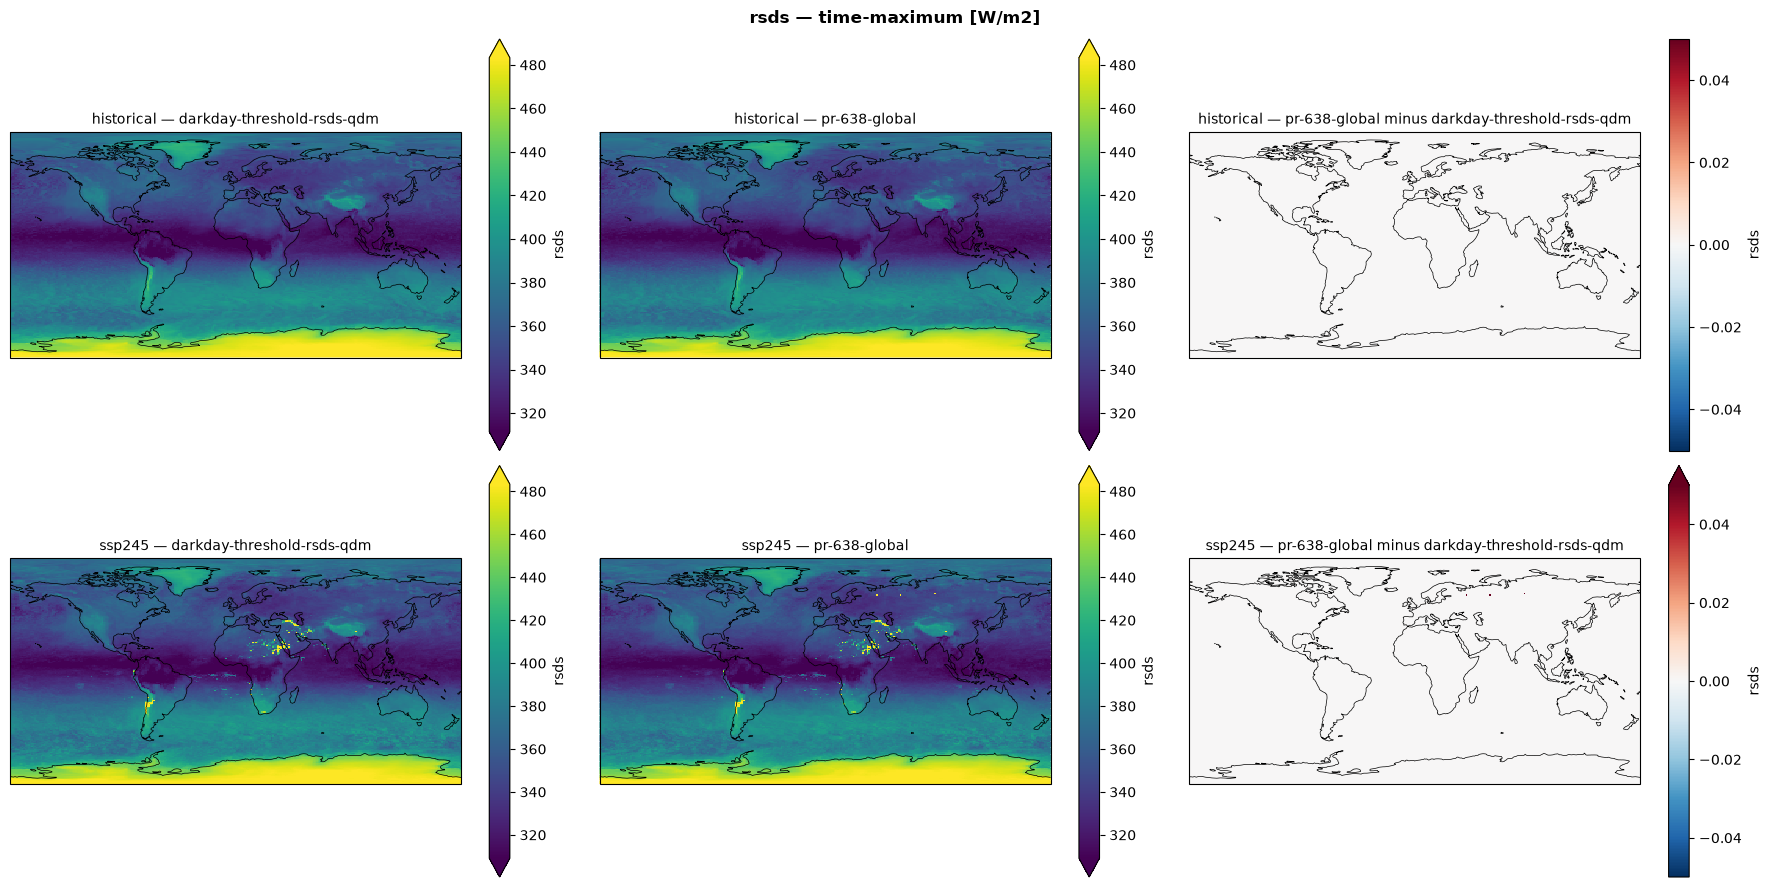

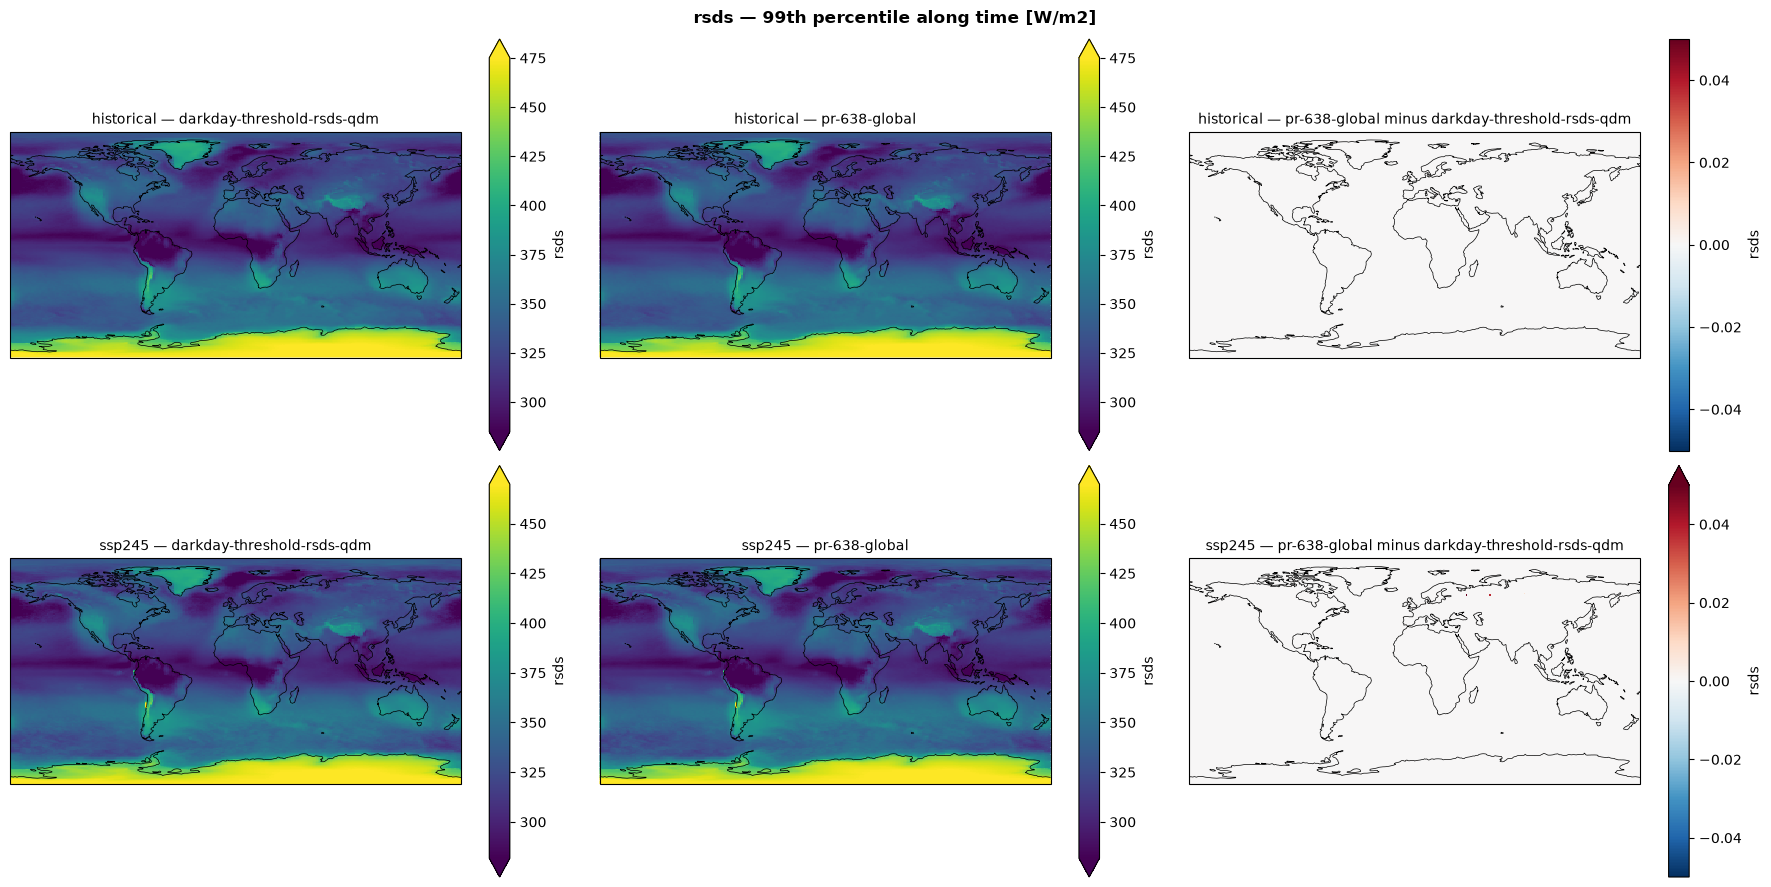

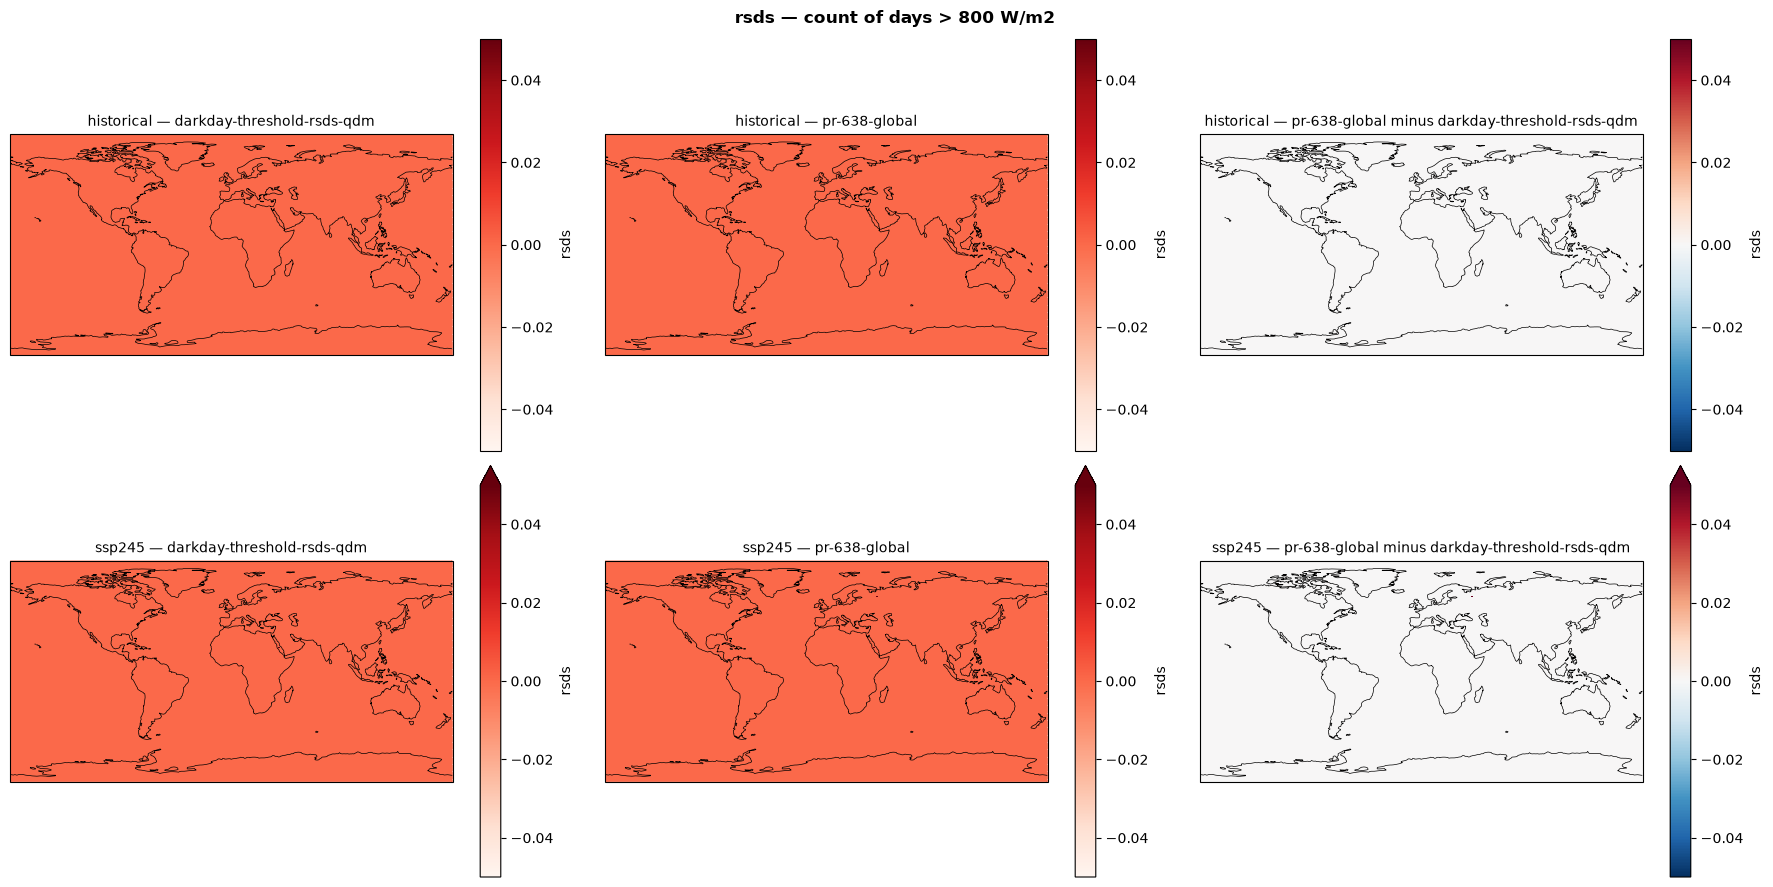

In [10]:
# Two rows of maps for `metric`: historical (store_a, store_b, diff) and ssp245 (store_a,
# store_b, diff).
def plot_metric_row(metric: str, title: str, *, cmap: str = "viridis", diff_cmap: str = "RdBu_r"):
    fig, axes = plt.subplots(2, 3, figsize=(18, 9), subplot_kw=dict(projection=ccrs.PlateCarree()))
    fig.suptitle(title, fontweight="bold")

    for row, period in enumerate(["historical", "ssp245"]):
        a_map = STATS[(period, "store_a")][metric]
        b_map = STATS[(period, "store_b")][metric]
        diff_map = b_map - a_map
        panels = [
            (a_map, f"{period} — {DATASET_LABELS['store_a']}", cmap, False),
            (b_map, f"{period} — {DATASET_LABELS['store_b']}", cmap, False),
            (
                diff_map,
                f"{period} — {DATASET_LABELS['store_b']} minus {DATASET_LABELS['store_a']}",
                diff_cmap,
                True,
            ),
        ]
        for ax, (da, panel_title, panel_cmap, center0) in zip(axes[row], panels):
            kw = dict(cmap=panel_cmap, robust=True, transform=ccrs.PlateCarree())
            if center0:
                kw["center"] = 0
            da.plot(ax=ax, **kw)
            ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
            ax.set_title(panel_title, fontsize=10)
            ax.set_xlabel(None)
            ax.set_ylabel(None)
    plt.tight_layout()
    plt.show()


plot_metric_row("time_max", f"{VARIABLE} — time-maximum [W/m2]")
plot_metric_row("p99", f"{VARIABLE} — 99th percentile along time [W/m2]")
plot_metric_row(
    "count_over_800",
    f"{VARIABLE} — count of days > {DARKDAY_COUNT_THRESHOLD_WM2:g} W/m2",
    cmap="Reds",
)

# Zoom in on one pixel with the artifact in Russia

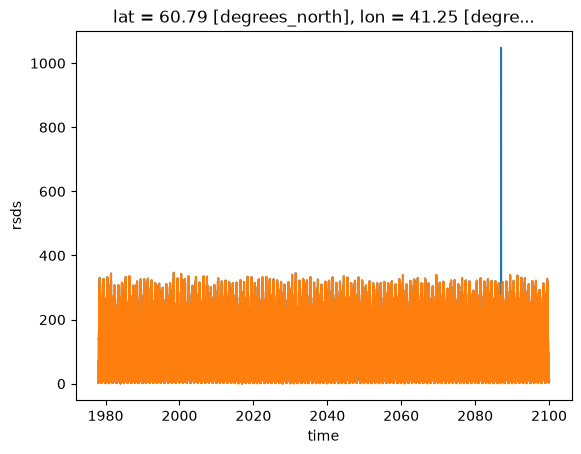

In [ ]:
dataset_b.sel(lat=slice(50, 75), lon=slice(30, 50)).sel(lat=61, lon=41, method="nearest").plot(
    label="main"
)
dataset_a.sel(lat=slice(50, 75), lon=slice(30, 50)).sel(lat=61, lon=41, method="nearest").plot(
    label="darkday-threshold-rsds-qdm"
)

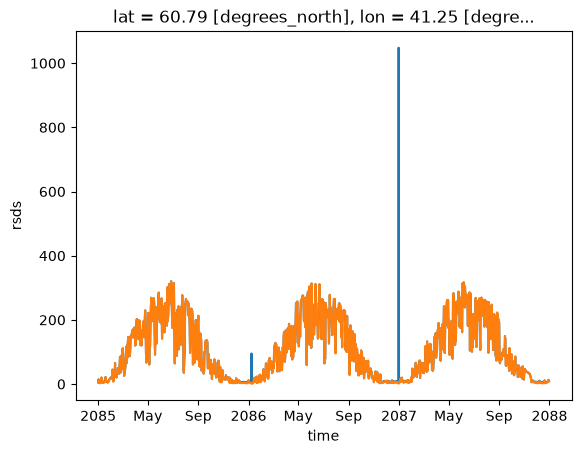

In [ ]:
dataset_b.sel(time=slice("2085", "2087")).sel(lat=61, lon=41, method="nearest").plot(label="main")
dataset_a.sel(time=slice("2085", "2087")).sel(lat=61, lon=41, method="nearest").plot(
    label="darkday-threshold-rsds-qdm"
)

# Not just artifact removal - there are also tiny differences

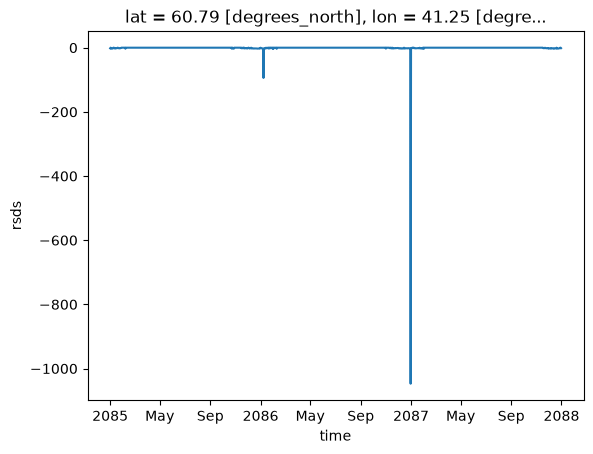

In [26]:
(dataset_a - dataset_b).sel(time=slice("2085", "2087")).sel(lat=61, lon=41, method="nearest").plot()

(-10.0, 10.0)

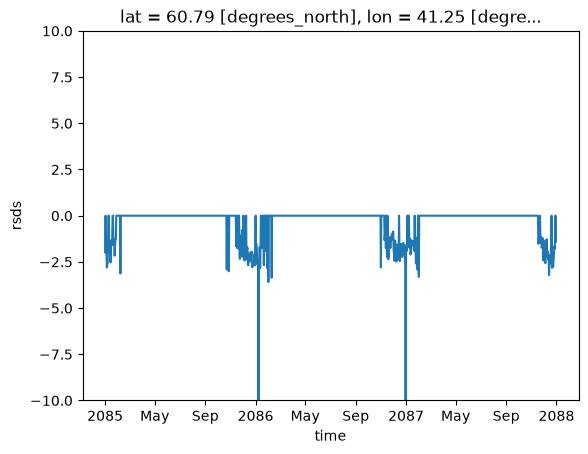

In [28]:
(dataset_a - dataset_b).sel(time=slice("2085", "2087")).sel(lat=61, lon=41, method="nearest").plot()
plt.ylim(-10, 10)

## Section 2 — delta-trend analysis vs. the raw GCM signal

Same six-panel, three-row comparison as the "Compare local run vs `pr-638-global` icechunk
store" section of `debugger-qdm-test-china.ipynb`, ported to compare `store_a`
(`darkday-threshold-rsds-qdm`) and `store_b` (`pr-638-global`) against the raw (un-bias-corrected)
GCM signal instead of a local pipeline run. Row 0 is the climate-change delta for each series;
row 1 is that delta minus the raw delta (bias-correction residual); row 2 is the
difference-of-deltas between the two stores. Column 0 (raw) has no residual/difference-of-deltas
row, and column 1 (`store_a`) has no difference-of-deltas row — both are turned off, matching the
china notebook's triangular layout, which is why only 6 of the 9 grid cells are populated.


In [ ]:
raw_hist = get_historical_experiment(gcm=GCM, member=HIST_MEMBER, var=VARIABLE).drop_vars(
    "spatial_ref", errors="ignore"
)
raw_scenario = (
    get_experiment(gcm=GCM, scenario=SCENARIO, var=VARIABLE)
    .sel(ensemble_member=ENSEMBLE_MEMBER)
    .drop_vars(["spatial_ref", "ensemble_member"], errors="ignore")
)
raw = xr.concat([raw_hist, raw_scenario], dim="time").sortby("time")
raw

<xarray.DataArray 'rsds' (time: 91311, lat: 192, lon: 288)> Size: 20GB
dask.array<getitem, shape=(91311, 192, 288), dtype=float32, chunksize=(150, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * time             (time) datetime64[ns] 730kB 1850-01-01 ... 2099-12-31
  * lat              (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
  * lon              (lon) float64 2kB -180.0 -178.8 -177.5 ... 177.5 178.8
    ensemble_member  <U8 32B 'r3i1p1f1'
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              W m-2
    long_name:          Downwelling solar flux at surface
    cell_methods:       time: mean

In [ ]:
VAR_PLOT = {
    "convert": lambda da: da,  # rsds is already W/m2, no conversion needed
    "units": "W/m2",
    "long_name": "rsds",
    "below_threshold_value": 1.0,  # a day with < 1 W/m2 mean insolation counts as "dark"
    "below_threshold_label": "dark days",
    "threshold_units": "W/m2",
    # Not hand-tuned like pr's in the china notebook -- falls back to per-panel robust scaling.
    "mean_abs_lims": None,
    "p99_abs_lims": None,
    "mean_abs_diff_of_deltas_lims": None,
    "p99_abs_diff_of_deltas_lims": None,
}

HISTORICAL_PERIOD = slice("1985", "2014")
FUTURE_PERIOD = slice("2060", "2090")

COMPARISON_APPROACHES = ["store_b"]
ds_dict = {"store_a": dataset_a, "store_b": dataset_b}

assert raw["time"].max().values >= np.datetime64(f"{FUTURE_PERIOD.stop}-12-31"), (
    f"raw GCM data only runs through {raw['time'].max().values} -- need data through {FUTURE_PERIOD.stop} for the delta-trend comparison below."
)

raw_c = VAR_PLOT["convert"](raw)
store_a_c = VAR_PLOT["convert"](ds_dict["store_a"])
approach_das = {
    approach: VAR_PLOT["convert"](ds_dict[approach]) for approach in COMPARISON_APPROACHES
}

In [36]:
BELOW_THRESHOLD = VAR_PLOT["below_threshold_value"]


# (future - historical) delta, plus the historical stat it was built from.
def cc_delta(da, metric="mean"):
    historical_period = slice("1985", "2014")
    future_period = slice("2030", "2059")
    if metric == "mean":
        hist_stat = da.sel(time=historical_period).mean("time")
        fut_stat = da.sel(time=future_period).mean("time")
    elif metric == "99p":
        hist_stat = da.sel(time=historical_period).quantile(0.99, dim="time")
        fut_stat = da.sel(time=future_period).quantile(0.99, dim="time")
    elif metric == "below_threshold":
        hist_stat = (da.sel(time=historical_period) < BELOW_THRESHOLD).mean("time") * 100
        fut_stat = (da.sel(time=future_period) < BELOW_THRESHOLD).mean("time") * 100
    return (fut_stat - hist_stat).compute(), hist_stat.compute()


def relative_delta(absolute_delta, hist_stat):
    return absolute_delta / hist_stat * 100

In [37]:
plot_dict = {"absolute": {}, "relative": {}}
for metric in ["mean", "99p", "below_threshold"]:
    print(metric)

    delta_raw, hist_raw = cc_delta(raw_c, metric=metric)
    delta_store_a, hist_store_a = cc_delta(store_a_c, metric=metric)
    store_a_minus_raw = delta_store_a - delta_raw
    rel_raw = relative_delta(delta_raw, hist_raw)
    rel_store_a = relative_delta(delta_store_a, hist_store_a)
    rel_store_a_minus_raw = rel_store_a - rel_raw

    abs_panels = {
        "Δ raw": [delta_raw, (0, 0)],
        "Δ store_a": [delta_store_a, (0, 1)],
        "Δ store_a - Δ raw": [store_a_minus_raw, (1, 1)],
    }
    rel_panels = {
        "Δ raw": [rel_raw, (0, 0)],
        "Δ store_a": [rel_store_a, (0, 1)],
        "Δ store_a - Δ raw": [rel_store_a_minus_raw, (1, 1)],
    }

    for col, approach in enumerate(COMPARISON_APPROACHES, start=2):
        delta_approach, hist_approach = cc_delta(approach_das[approach], metric=metric)
        approach_minus_raw = delta_approach - delta_raw
        abs_panels[f"Δ {approach}"] = [delta_approach, (0, col)]
        abs_panels[f"Δ {approach} - Δ raw"] = [approach_minus_raw, (1, col)]
        abs_panels[f"difference of deltas ({approach} - store_a)"] = [
            approach_minus_raw - store_a_minus_raw,
            (2, col),
        ]

        rel_approach = relative_delta(delta_approach, hist_approach)
        rel_approach_minus_raw = rel_approach - rel_raw
        rel_panels[f"Δ {approach}"] = [rel_approach, (0, col)]
        rel_panels[f"Δ {approach} - Δ raw"] = [rel_approach_minus_raw, (1, col)]
        rel_panels[f"difference of deltas ({approach} - store_a)"] = [
            rel_approach_minus_raw - rel_store_a_minus_raw,
            (2, col),
        ]

    plot_dict["absolute"][metric] = abs_panels
    plot_dict["relative"][metric] = rel_panels

mean
99p
below_threshold


In [ ]:
_N_COLS = 2 + len(COMPARISON_APPROACHES)  # raw, store_a, + one column per comparison approach
_N_ROWS = 3  # row 0: delta; row 1: delta - delta raw; row 2: difference of deltas vs store_a

_METRIC_ABS_LIMS = {
    "mean": VAR_PLOT["mean_abs_lims"],
    "99p": VAR_PLOT["p99_abs_lims"],
    "below_threshold": (-20, 20),
}
_METRIC_ABS_DIFF_OF_DELTAS_LIMS = {
    "mean": VAR_PLOT["mean_abs_diff_of_deltas_lims"],
    "99p": VAR_PLOT["p99_abs_diff_of_deltas_lims"],
    "below_threshold": (-10, 10),
}
_REL_LIMS = (-5, 5)
_REL_DIFF_OF_DELTAS_LIMS = (-5, 5)

var_lims_dict = {"absolute": {}, "relative": {}}
for metric, abs_lims in _METRIC_ABS_LIMS.items():
    diff_of_deltas_lims = _METRIC_ABS_DIFF_OF_DELTAS_LIMS[metric]
    var_lims_dict["absolute"][metric] = {}
    var_lims_dict["relative"][metric] = {"Δ raw": _REL_LIMS, "Δ store_a": _REL_LIMS}
    if abs_lims is not None:
        var_lims_dict["absolute"][metric]["Δ raw"] = abs_lims
        var_lims_dict["absolute"][metric]["Δ store_a"] = abs_lims
        var_lims_dict["absolute"][metric]["Δ store_a - Δ raw"] = abs_lims
    for approach in COMPARISON_APPROACHES:
        if abs_lims is not None:
            var_lims_dict["absolute"][metric][f"Δ {approach}"] = abs_lims
            var_lims_dict["absolute"][metric][f"Δ {approach} - Δ raw"] = abs_lims
        if diff_of_deltas_lims is not None:
            var_lims_dict["absolute"][metric][f"difference of deltas ({approach} - store_a)"] = (
                diff_of_deltas_lims
            )
        var_lims_dict["relative"][metric][f"Δ {approach}"] = _REL_LIMS
        var_lims_dict["relative"][metric][f"difference of deltas ({approach} - store_a)"] = (
            _REL_DIFF_OF_DELTAS_LIMS
        )

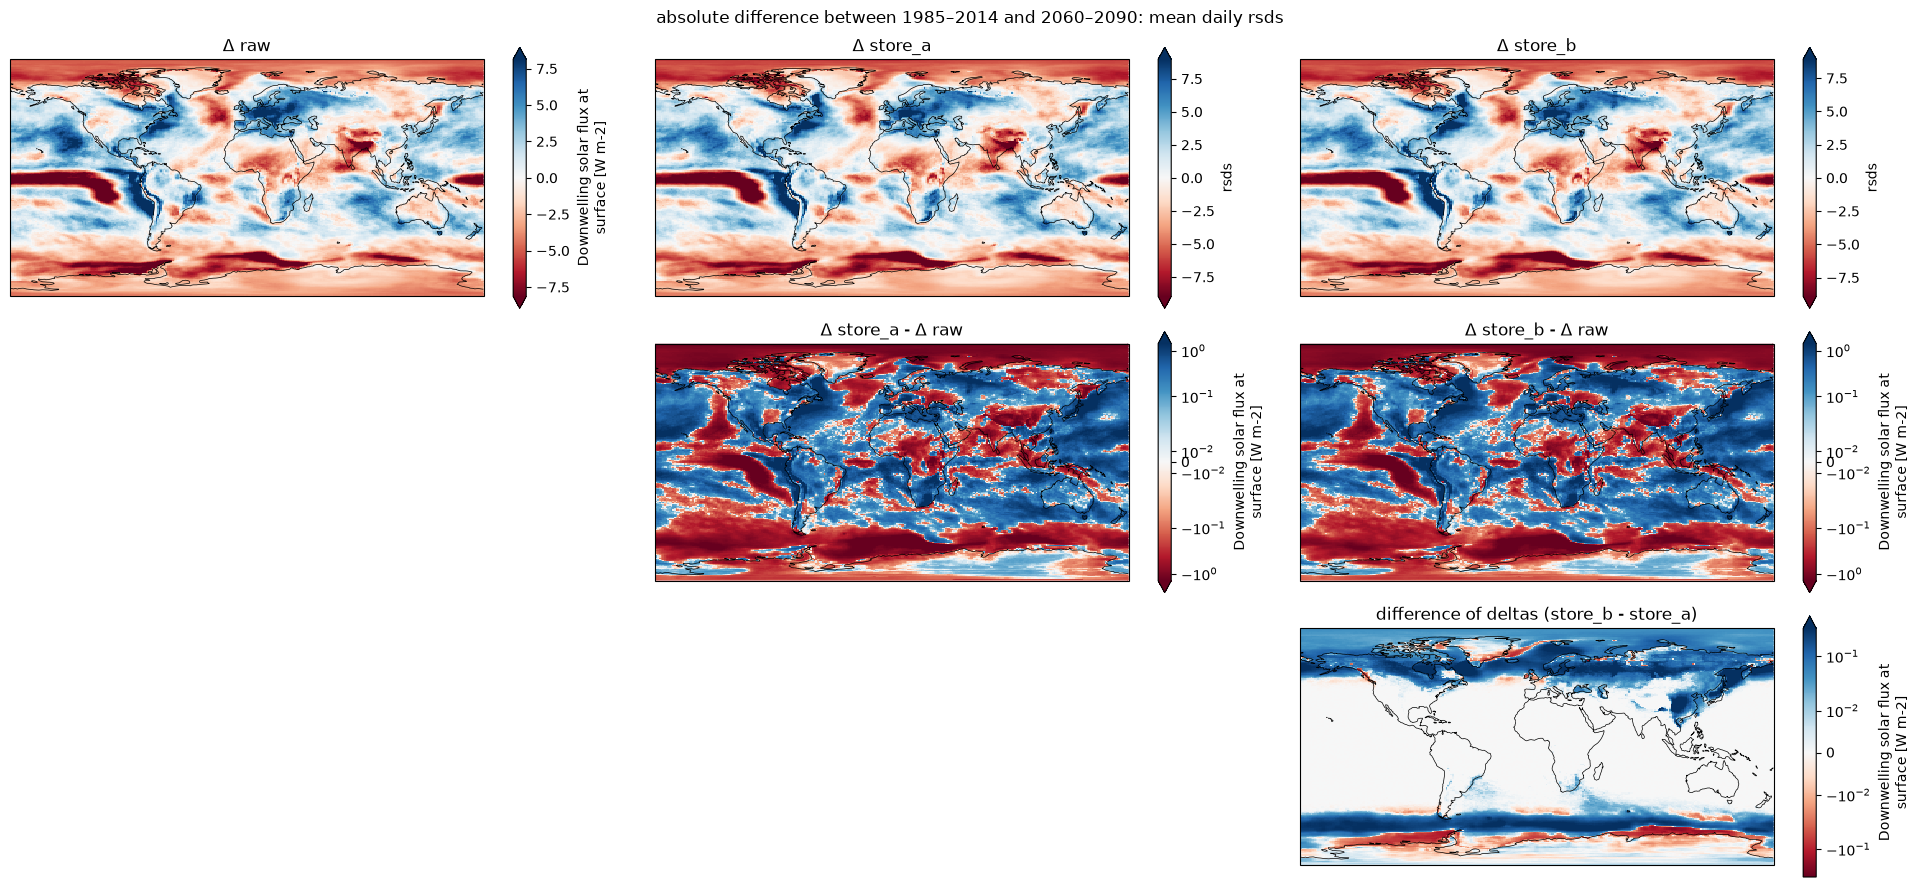

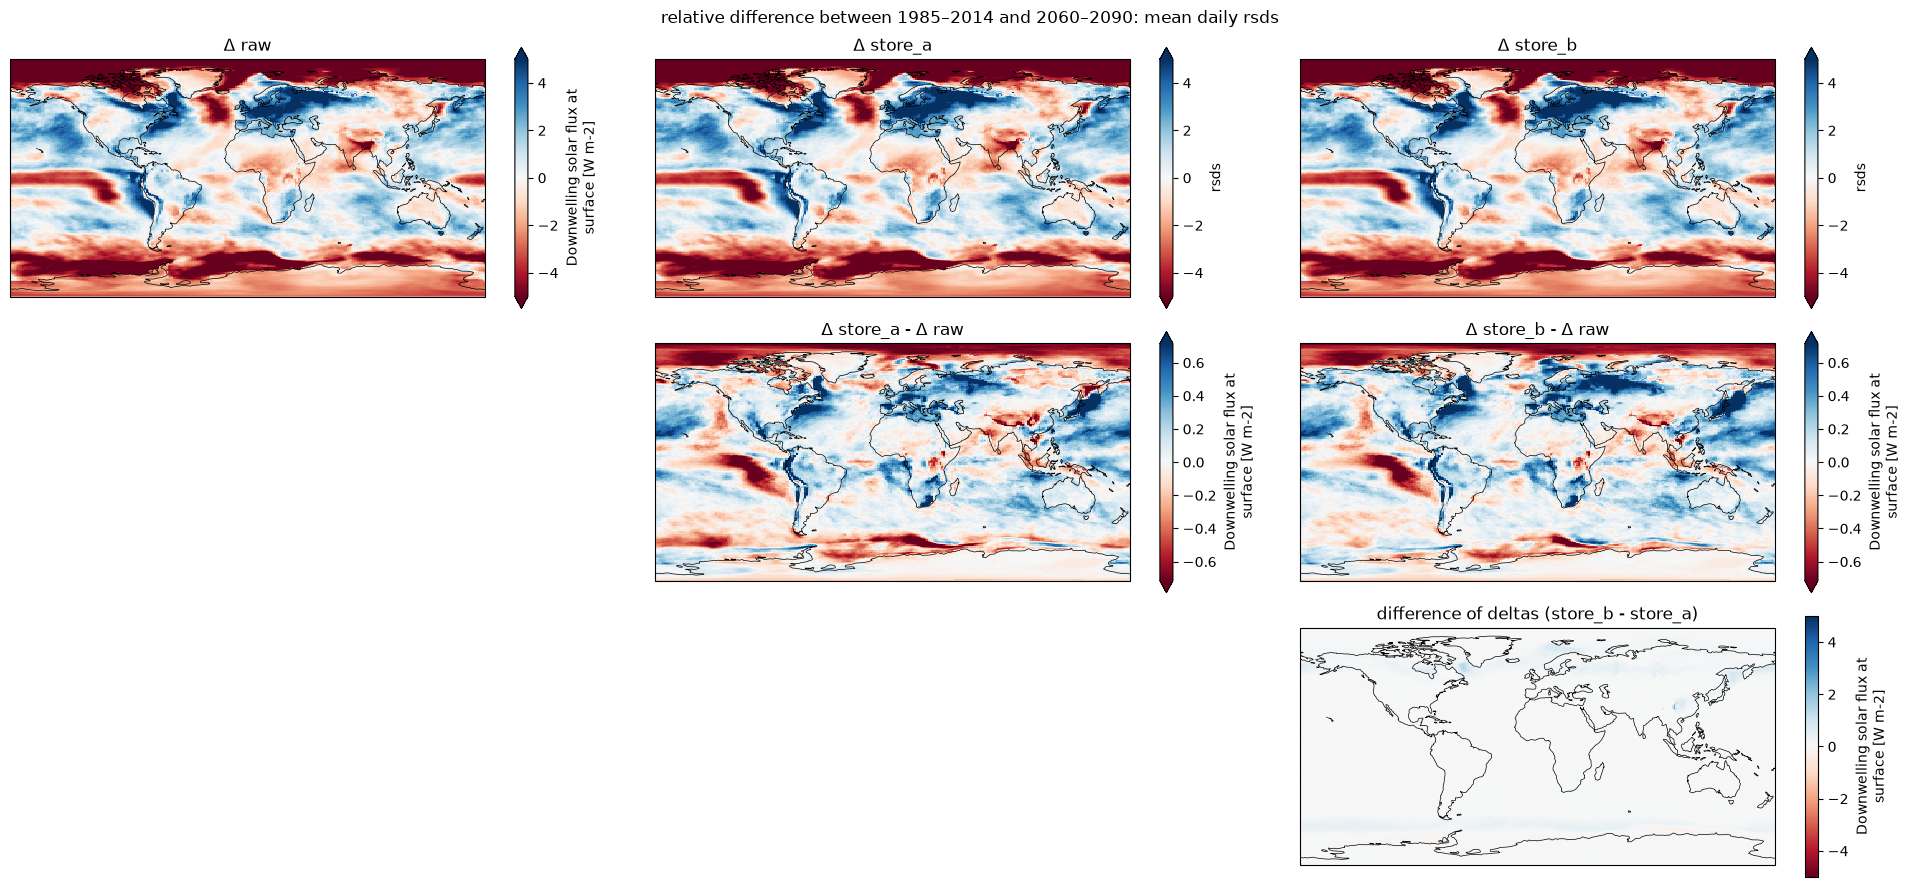

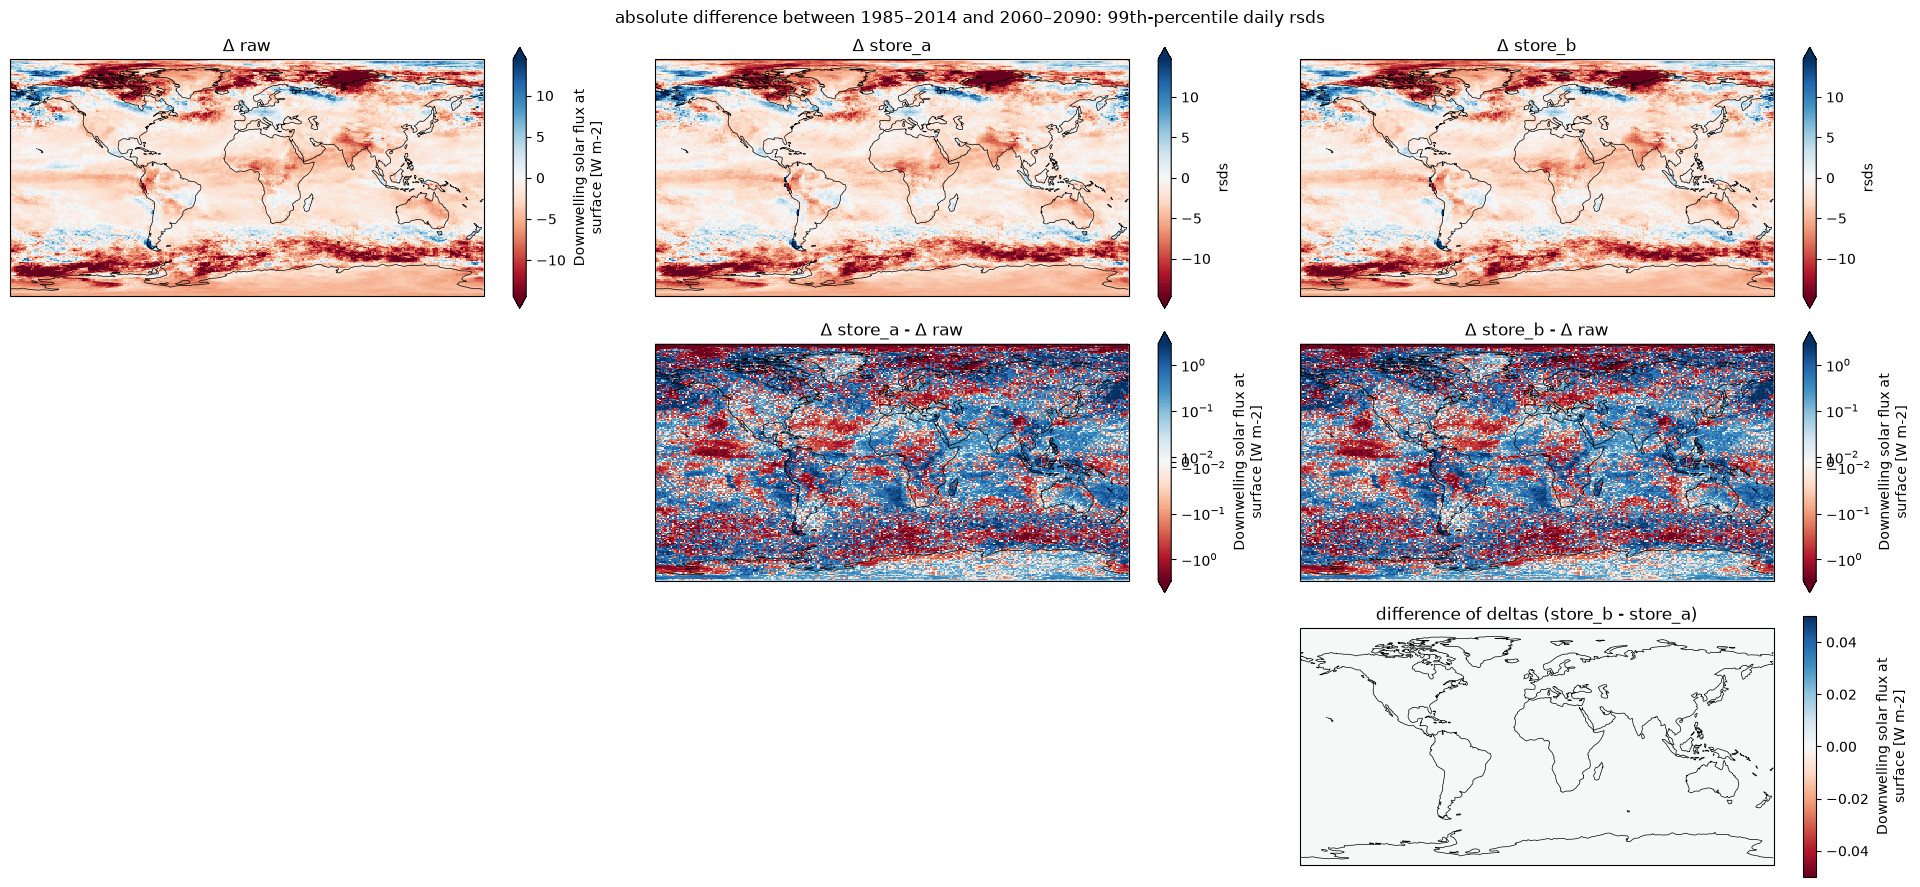

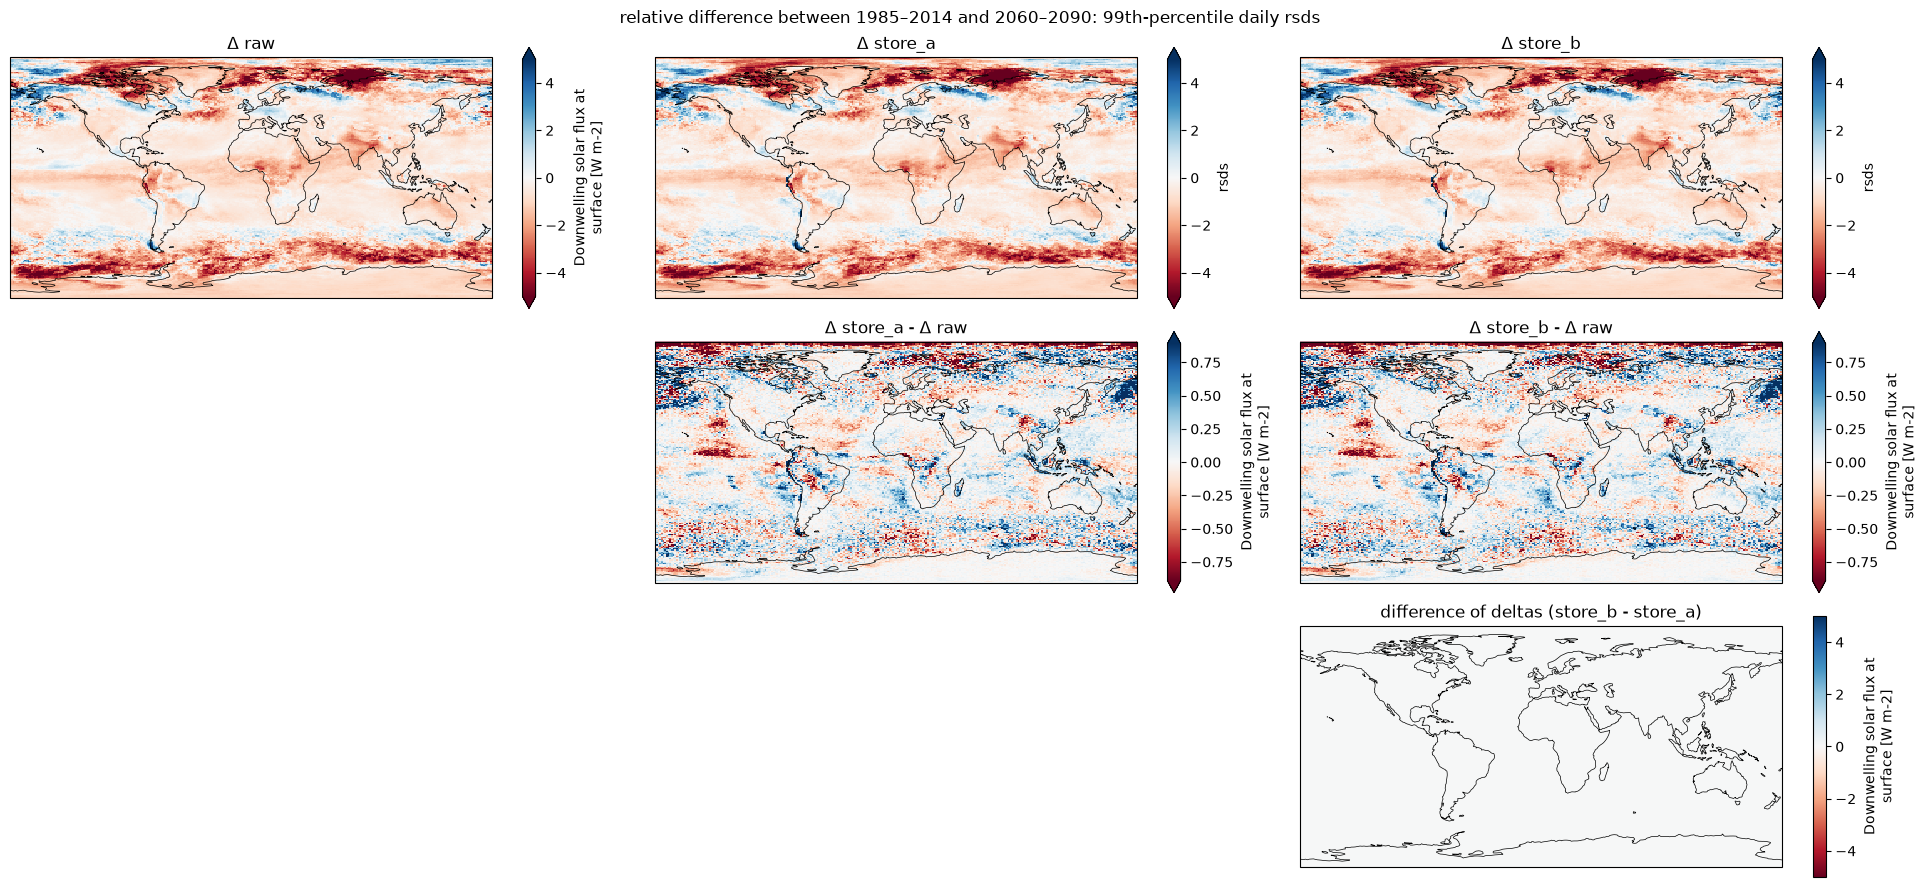

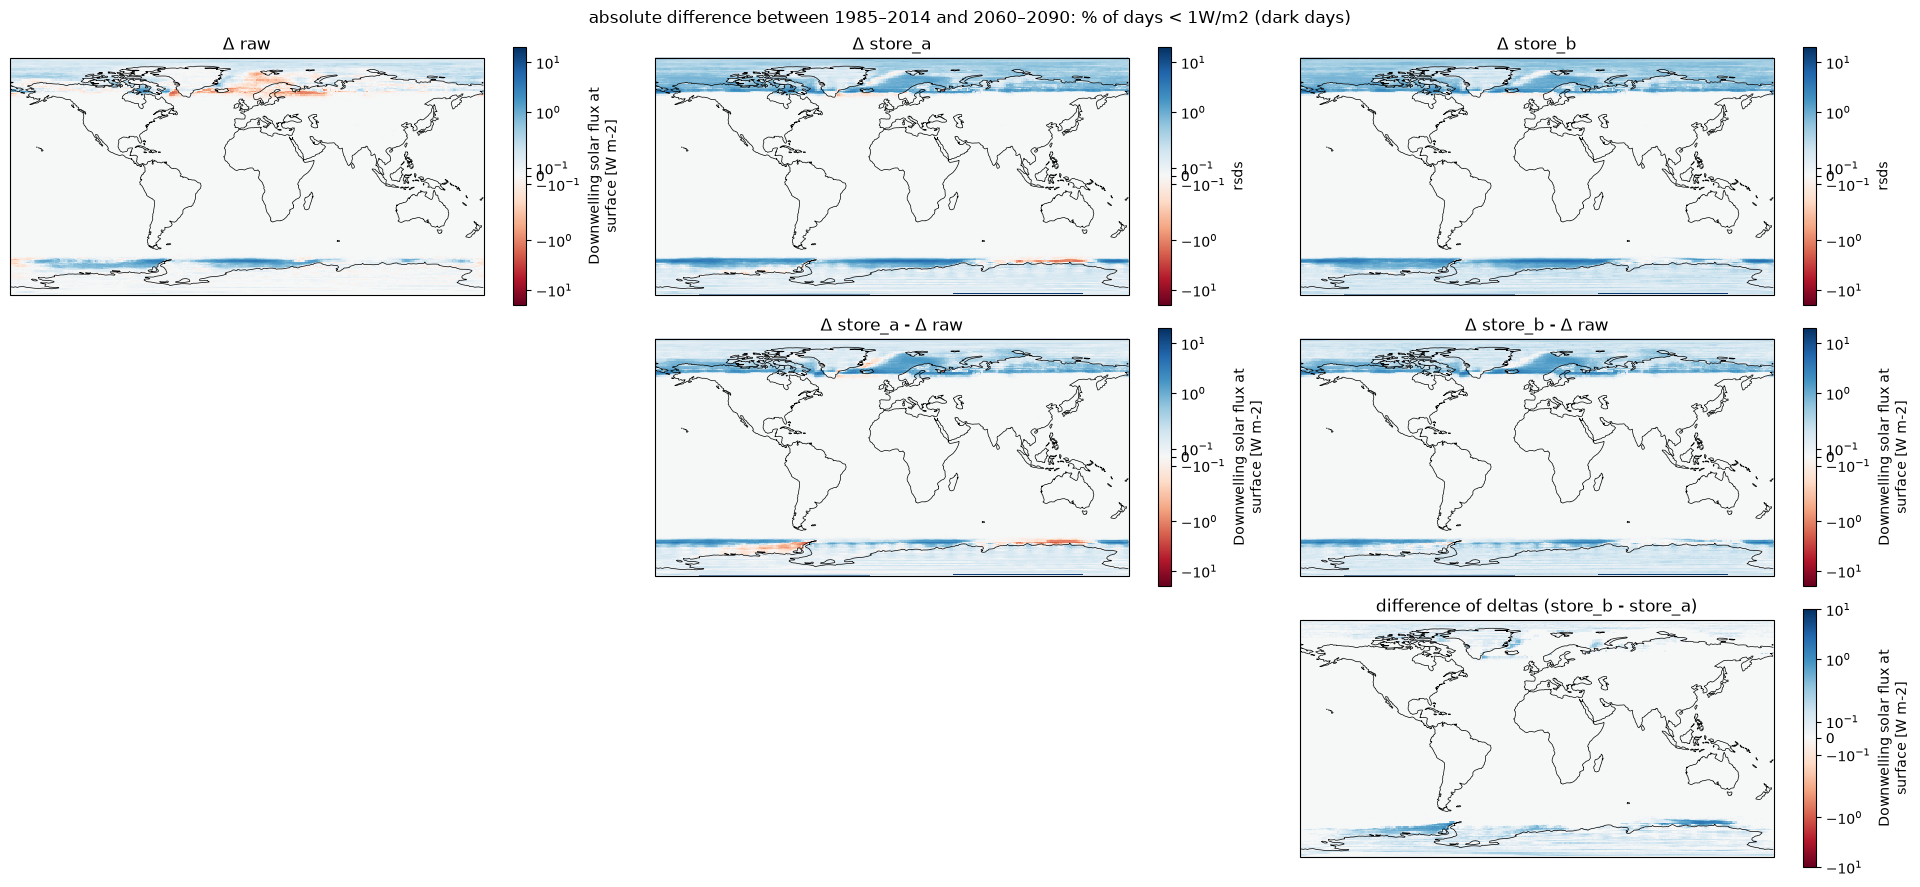

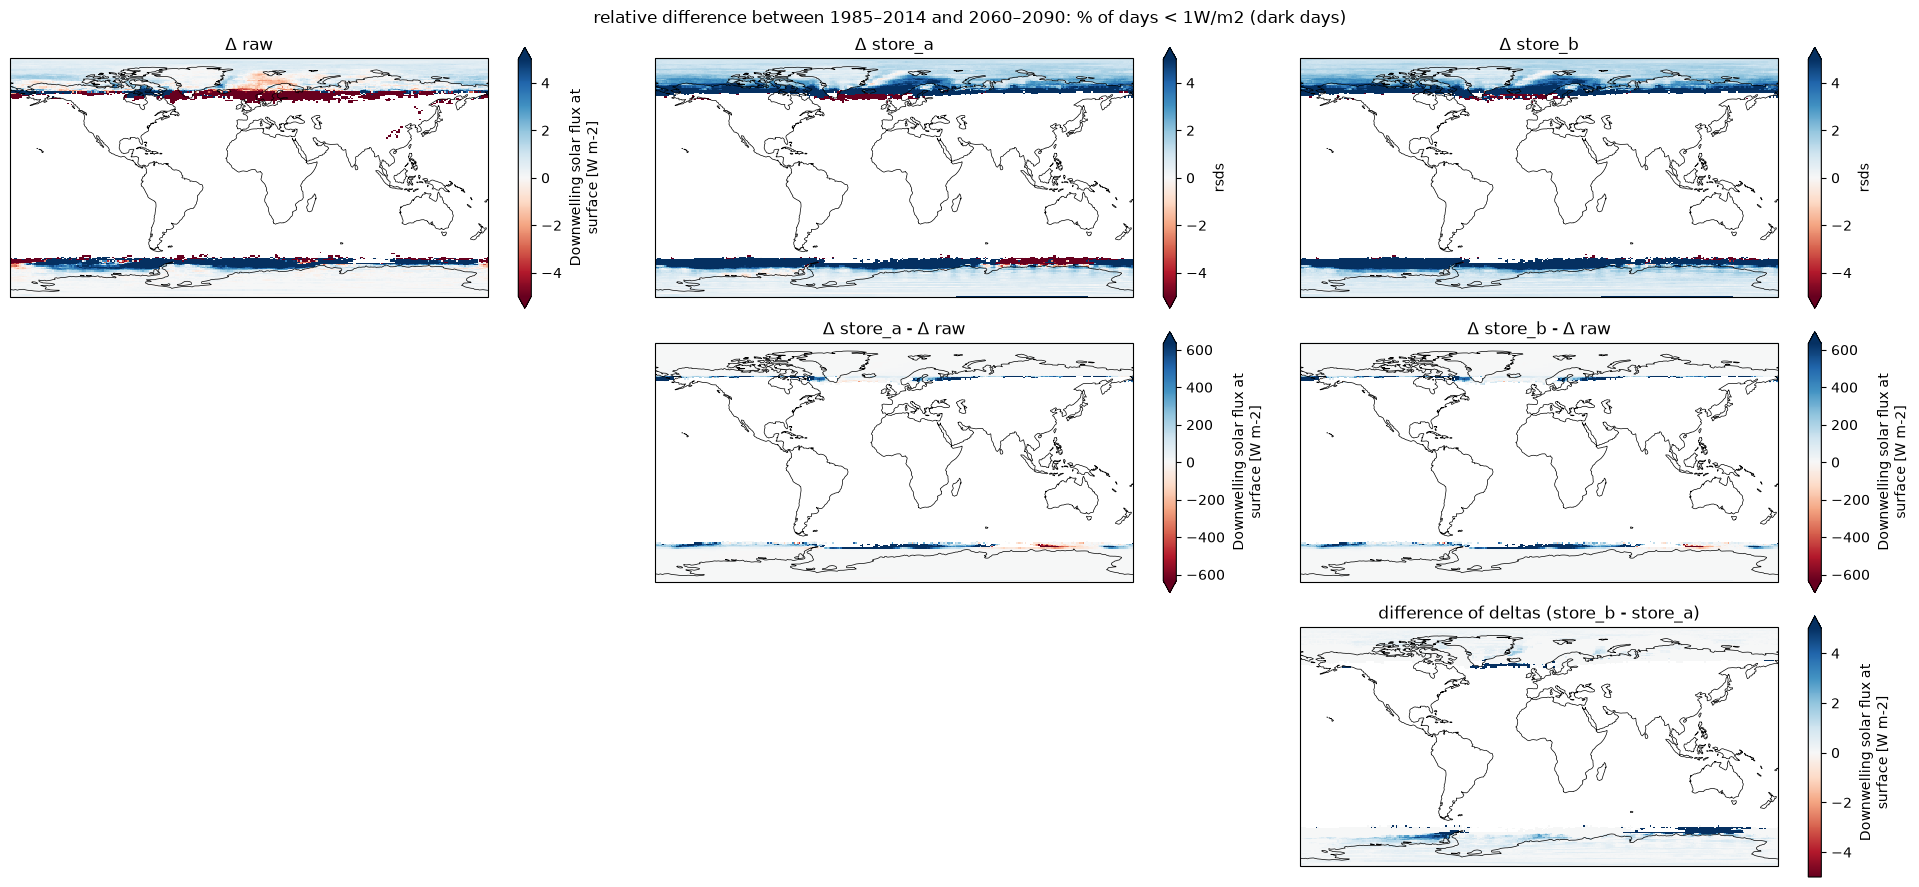

In [ ]:
_proj_kw = dict(projection=ccrs.PlateCarree())
_transform_kw = dict(transform=ccrs.PlateCarree())

_METRIC_LABELS = {
    "mean": f"mean daily {VAR_PLOT['long_name']}",
    "99p": f"99th-percentile daily {VAR_PLOT['long_name']}",
    "below_threshold": f"% of days < {BELOW_THRESHOLD:g}{VAR_PLOT['threshold_units']} ({VAR_PLOT['below_threshold_label']})",
}

_RESIDUAL_TITLES = ("Δ store_a - Δ raw",) + tuple(
    f"Δ {approach} - Δ raw" for approach in COMPARISON_APPROACHES
)
_DIFF_OF_DELTAS_TITLES = tuple(
    f"difference of deltas ({approach} - store_a)" for approach in COMPARISON_APPROACHES
)


# Symmetric-around-zero robust (2nd/98th percentile) limits pooled across arrays.
def _shared_robust_center0_limits(*das):
    combined = np.concatenate([np.asarray(da.values).ravel() for da in das])
    combined = combined[np.isfinite(combined)]
    p2, p98 = np.nanpercentile(combined, [2, 98])
    vlim = max(abs(p2), abs(p98))
    return -vlim, vlim


# var_lims_dict values where present; a pooled robust range for the rest.
def _shared_lims(method, metric, titles):
    lims = {
        t: var_lims_dict[method][metric][t] for t in titles if t in var_lims_dict[method][metric]
    }
    if len(lims) < len(titles):
        shared_vmin, shared_vmax = _shared_robust_center0_limits(
            *(plot_dict[method][metric][t][0] for t in titles)
        )
        for t in titles:
            lims.setdefault(t, (shared_vmin, shared_vmax))
    return lims


for metric in ["mean", "99p", "below_threshold"]:
    for method in ["absolute", "relative"]:
        fig, axes = plt.subplots(_N_ROWS, _N_COLS, figsize=(6.5 * _N_COLS, 9), subplot_kw=_proj_kw)

        shared_lims = {
            **_shared_lims(method, metric, _RESIDUAL_TITLES),
            **_shared_lims(method, metric, _DIFF_OF_DELTAS_TITLES),
        }

        for title, [da, (i, j)] in plot_dict[method][metric].items():
            lims = (
                shared_lims[title]
                if title in shared_lims
                else var_lims_dict[method][metric].get(title)
            )
            # A SymLogNorm needs a strictly positive linthresh, but a residual /
            # difference-of-deltas panel can pool to vmax <= 0 -- e.g. QDM keeps the
            # bias-corrected delta close to the raw delta by construction, so "Δ approach -
            # Δ raw" can be ~exactly zero across the robust 2nd-98th percentile range. Fall
            # back to a plain diverging robust scale in that case instead of forcing a
            # degenerate log norm (also covers lims[1] being NaN, e.g. an all-NaN panel).
            if lims is not None and method == "absolute" and lims[1] > 0:
                vmin, vmax = lims
                norm = SymLogNorm(linthresh=vmax / 30, vmin=vmin, vmax=vmax)
                da.plot(ax=axes[i, j], norm=norm, cmap="RdBu", **_transform_kw)
            elif lims is not None and method != "absolute":
                vmin, vmax = lims
                da.plot(ax=axes[i, j], vmin=vmin, vmax=vmax, cmap="RdBu", **_transform_kw)
            else:
                da.plot(ax=axes[i, j], robust=True, cmap="RdBu", center=0, **_transform_kw)
            axes[i, j].add_feature(cfeature.COASTLINE, linewidth=0.5)
            axes[i, j].set_title(title)
            axes[i, j].set_xlabel(None)
            axes[i, j].set_ylabel(None)
        # No "raw - raw" residual and no "store_a - store_a" difference of deltas.
        axes[1, 0].set_axis_off()
        axes[2, 0].set_axis_off()
        axes[2, 1].set_axis_off()
        fig.suptitle(
            f"{method} difference between {HISTORICAL_PERIOD.start}–{HISTORICAL_PERIOD.stop} and {FUTURE_PERIOD.start}–{FUTURE_PERIOD.stop}: {_METRIC_LABELS.get(metric, metric)}"
        )
        plt.tight_layout()
        plt.show()